In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import sys
import re
import json
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
from scipy import signal
import ddddocr
import torch
from torchvision.models import resnet18, ResNet18_Weights

In [2]:
pf = pd.DataFrame(os.listdir(os.path.join("source", "data")), columns=["filename"])
pf.T

,0,1,2,3,4,5,6,7,8,9,10
filename,btn_gift.png,frame.jpg,frame2.jpg,frame3.jpg,main.png,main2.png,page.png,receive.png,side.png,side2.png,side3.png


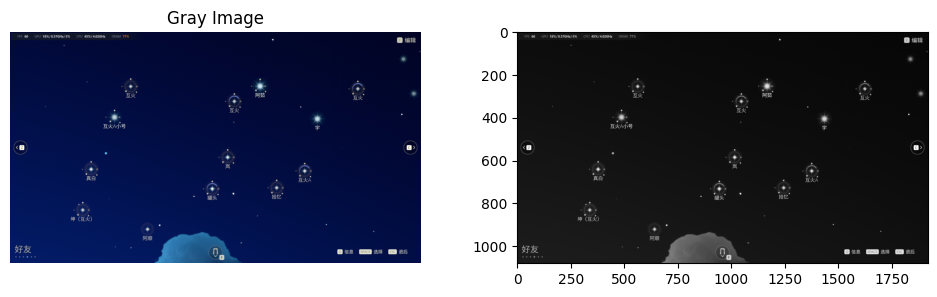

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12,3))

# 读取一下图片进行测试
image = cv2.imread(os.path.join("source", "data", "side.png"))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

axes[0].imshow(image)
axes[0].axis('off')
axes[0].set_title("Origin Image")
axes[1].imshow(gray, cmap="gray")
axes[0].axis('off')
axes[0].set_title("Gray Image")
plt.show()

---
# 霍夫变换 - 圆形检测

效果比滤波之后的强很多, 游戏界面不需要怎么滤波, 注意不要有其他陌生人就行 (霍夫变换还是准备废弃了)

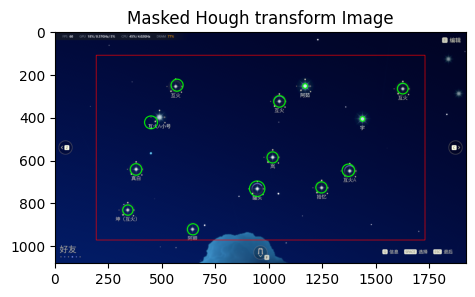

In [4]:
min_radius=1
max_radius=100

# 边界去除
height, width = gray.shape
border_ratio = 0.1
mask = np.zeros_like(gray, dtype=np.uint8)
border_x = int(width * border_ratio)
border_y = int(height * border_ratio)
inner_width = width - 2 * border_x
inner_height = height - 2 * border_y

cv2.rectangle(mask, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, -1)
masked_edges = cv2.bitwise_and(mask, gray, mask=mask)

# 使用霍夫圆变换检测圆形
circles = cv2.HoughCircles(
    masked_edges,               # 输入图像（边缘图）
    cv2.HOUGH_GRADIENT,         # 检测方法（梯度法）
    dp=1,                       # 累加器图像的分辨率与原图之比
    minDist=50,                 # 检测到的圆的圆心之间的最小距离
    param1=50,                  # Canny边缘检测器的高阈值
    param2=30,                  # 累加器阈值（越小检测到的圆越多）
    minRadius=min_radius,       # 最小圆半径
    maxRadius=max_radius        # 最大圆半径
)

# 复制原图用于绘制结果
result = image.copy()
cv2.rectangle(result, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, 2)

if circles is not None:
    circles = np.round(circles[0, :]).astype("int")
    for (x, y, r) in circles:
        cv2.circle(result, (x, y), r, (0, 255, 0), 4)
else:
    print("No detection.")


fig, axes = plt.subplots(1, 1, figsize=(10, 3))
axes.imshow(result, cmap="gray")
axes.set_title("Masked Hough transform Image")
plt.show()

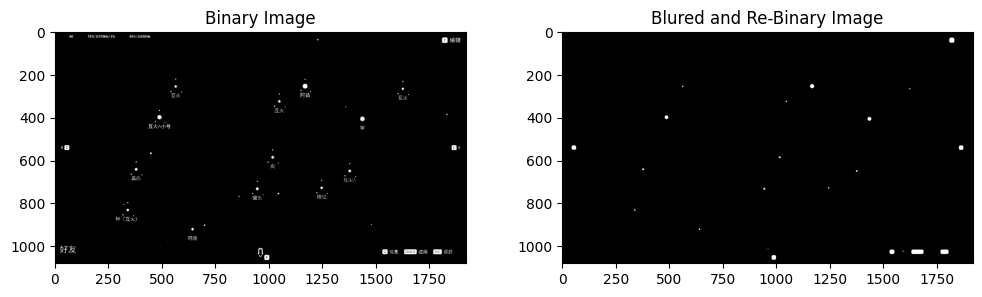

In [5]:
# 对灰度图进行二值化
_, binary_image = cv2.threshold(gray, 155, 255, cv2.THRESH_BINARY)
# 高斯平滑后再采样
blured_image = cv2.blur(binary_image, (9,9))
median_image = cv2.medianBlur(blured_image, 7)
# 重新二值化采样
_, rebinary_image = cv2.threshold(median_image, 155, 255, cv2.THRESH_BINARY)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].imshow(binary_image, cmap="gray")
axes[0].set_title("Binary Image")
axes[1].imshow(rebinary_image, cmap="gray")
axes[1].set_title("Blured and Re-Binary Image")
plt.show()

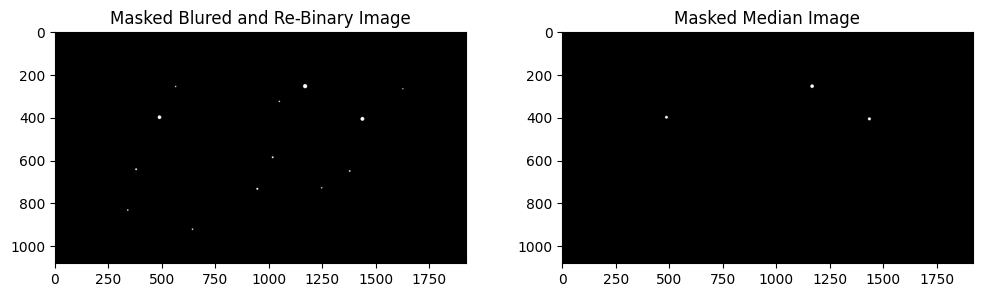

In [6]:
# 掩膜
height, width = gray.shape
border_ratio = 0.1
mask = np.zeros_like(gray, dtype=np.uint8)
border_x = int(width * border_ratio)
border_y = int(height * border_ratio)
inner_width = width - 2 * border_x
inner_height = height - 2 * border_y

cv2.rectangle(mask, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, -1)
masked_rebinary_image = cv2.bitwise_and(mask, rebinary_image, mask=mask)

masked_median_image = cv2.medianBlur(cv2.medianBlur(masked_rebinary_image, 11), 11)

fig, axes = plt.subplots(1, 2, figsize=(12,3))
axes[0].imshow(masked_rebinary_image, cmap="gray")
axes[0].set_title("Masked Blured and Re-Binary Image")
axes[1].imshow(masked_median_image, cmap="gray")
axes[1].set_title("Masked Median Image")
plt.show()

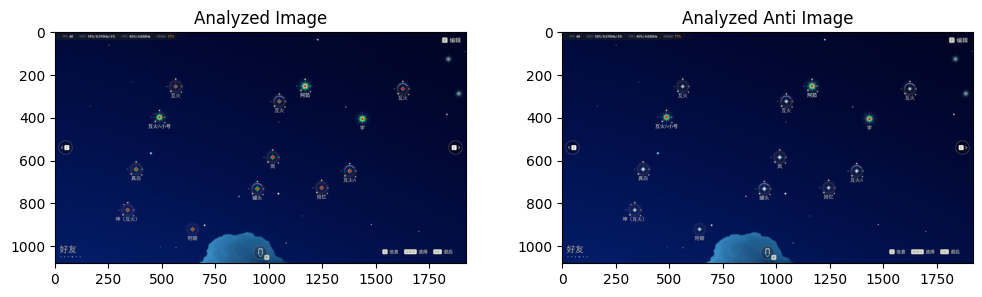

In [7]:
# 提取大范围亮色特征 (轮廓分析)
targets = []
origin_image = image.copy()
contours, _ = cv2.findContours(masked_rebinary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    center_x = x + w // 2
    center_y = y + h // 2
    targets.append((center_x, center_y))
    
    cv2.rectangle(origin_image, (x, y), (x+w, y+h), (0, 255, 0), 2)  # 绿色矩形
    cv2.circle(origin_image, (center_x, center_y), 5, (255, 0, 0), -1)  # 红色点

anti_image = image.copy()
acontours, _ = cv2.findContours(masked_median_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in acontours:
    x, y, w, h = cv2.boundingRect(contour)
    center_x = x + w // 2
    center_y = y + h // 2
    targets.append((center_x, center_y))
    
    cv2.rectangle(anti_image, (x, y), (x+w, y+h), (0, 255, 0), 2)  # 绿色矩形
    cv2.circle(anti_image, (center_x, center_y), 5, (255, 0, 0), -1)  # 红色点

fig, axes = plt.subplots(1, 2, figsize=(12,3))
axes[0].imshow(origin_image)
axes[0].set_title("Analyzed Image")
axes[1].imshow(anti_image)
axes[1].set_title("Analyzed Anti Image")
plt.show()

---
# FFT 滤波与 Canny 算子 (废弃案)

高斯滤波器的算法是这样的 $ G(x,y) = e^{-\frac{x^2+y^2}{\sigma^2}} $，我们对它取减法就获得了高通滤波器

归一化算法 $ V_{new} = \frac{V_{old} - min(V_{olds})}{max(V_{olds}) - min(V_{olds})} \times 255 $

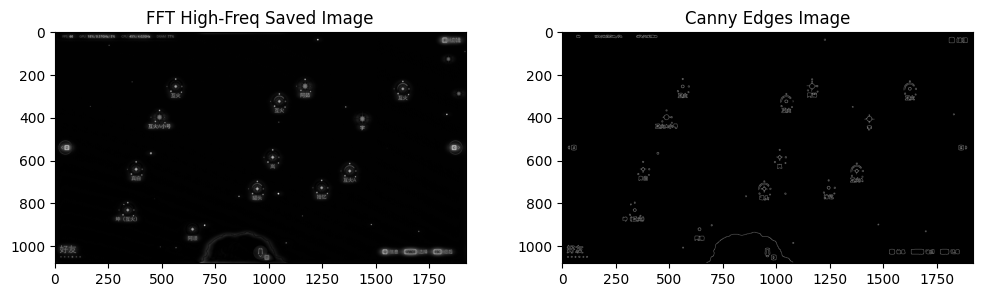

In [8]:
# 二维快速傅里叶变换, 抑制低频信号
f = np.fft.fft2(gray)
f_shift = np.fft.fftshift(f)

rows, cols = gray.shape
crow, ccol = rows//2, cols//2
sigma = 20
# 创建二维坐标网格，计算每个点到图像中心的偏移量
y, x = np.ogrid[-crow:rows-crow, -ccol:cols-ccol]
mask_gaussian_high = 1 - np.exp(-(x*x + y*y)/(2*sigma**2))

# 与掩码相乘实现滤波
f_filtered_high = f_shift * mask_gaussian_high
# 逆中心化、FFT 逆变换、有理化
f_ishift_high = np.fft.ifftshift(f_filtered_high)
img_filtered_high = np.fft.ifft2(f_ishift_high)
img_filtered_high = np.abs(img_filtered_high)

# 像素值归一化后整数化
fft_image = np.uint8(cv2.normalize(img_filtered_high, None, 0, 255, cv2.NORM_MINMAX))

# Canny 算子
canny_threshold1=50
canny_threshold2=150

# 高斯模糊并边缘化
blurred = cv2.GaussianBlur(gray, (9, 9), 2)
edges = cv2.Canny(blurred, canny_threshold1, canny_threshold2)

fig, axes = plt.subplots(1, 2, figsize=(12,3))
axes[0].imshow(fft_image, cmap="gray")
axes[0].set_title("FFT High-Freq Saved Image")
axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Canny Edges Image")
plt.show()

---
# ddddocr 文字提取获取星盘状态


OCR 识别结果: "好友", 坐标: [20, 23, 60, 61], [60, 22, 99, 61]


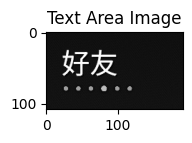

In [9]:
ocr = ddddocr.DdddOcr(show_ad=False)
text_detector = ddddocr.DdddOcr(det=True, show_ad=False)

# 边界去除
height, width = gray.shape
border_ratio = 0.1
mask = np.zeros_like(gray, dtype=np.uint8)
border_x = int(width * border_ratio)
border_y = int(height * border_ratio)

text_area = gray[height-border_y:, :border_x]

fig, axes = plt.subplots(1, 1, figsize=(3, 1))
axes.imshow(text_area, cmap='gray')
axes.set_title("Text Area Image")

_, encoded_img = cv2.imencode('.png', text_area)
img_bytes = encoded_img.tobytes()

result = ocr.classification(img_bytes)
det = text_detector.detection(img_bytes)

print("\nOCR 识别结果: \"{}\", 坐标: {}".format(result , ', '.join([str(det) for det in det])))

---
# 正则表达式匹配规则

In [10]:
def re_keyword_detector(texts):
    """
    ASCII字符清洗检测子串, 子串是提前规定好的
    """
    patterns = [r'添[\x00-\x7F]{0,3}加[\x00-\x7F]{0,3}好[\x00-\x7F]{0,3}友', r'好[\x00-\x7F]{0,3}友', r'挚[\x00-\x7F]{0,3}友']
    dataframes = {
        '识别文本': [],
        '星盘页': [],
        '添加好友': [],
        '好友': [],
        '挚友': [],
    }

    for text in texts:
        matchs = list([bool(re.search(pattern, text)) for pattern in patterns])
        dataframes['星盘页'].append(True in matchs)
        dataframes['添加好友'].append(matchs[0] == True)
        dataframes['好友'].append(matchs[1] == True)
        dataframes['挚友'].append(matchs[2] == True)
        dataframes['识别文本'].append(text)
        
    return pd.DataFrame(dataframes)

texts = ['你~好~~~', '添加好友，同意一下', '好$*友', '']

pf = re_keyword_detector(texts)
pf

,识别文本,星盘页,添加好友,好友,挚友
0,你~好~~~,False,False,False,False
1,添加好友，同意一下,True,True,True,False
2,好$*友,True,False,True,False
3,,False,False,False,False


---
# 使用亮度检测将所有内容提取出来

In [11]:
def threhold_detector(gray, plot=False, show=False):
    '''
    利用检测点的圆形高亮特性确定目标点
    '''
    # 一顿操作最后只剩下需要的信息
    _, binary_image = cv2.threshold(gray, 155, 255, cv2.THRESH_BINARY)
    blured_image = cv2.blur(binary_image, (9,9))
    median_image = cv2.medianBlur(blured_image, 7)
    _, rebinary_image = cv2.threshold(median_image, 155, 255, cv2.THRESH_BINARY)
    
    # 掩膜
    height, width = gray.shape
    border_ratio = 0.1
    mask = np.zeros_like(gray, dtype=np.uint8)
    border_x = int(width * border_ratio)
    border_y = int(height * border_ratio)
    inner_width = width - 2 * border_x
    inner_height = height - 2 * border_y
    cv2.rectangle(mask, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, -1)
    masked_rebinary_image = cv2.bitwise_and(mask, rebinary_image, mask=mask)
    
    # 提取大范围亮色特征 (轮廓分析)
    targets, anti_targets = [], []
    origin_image = None
    if plot:
        origin_image = image.copy()
        # 绘制掩膜
        cv2.rectangle(origin_image, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, 2)

    # 抓住所有需要的点特征
    contours, _ = cv2.findContours(masked_rebinary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        center_x, center_y = x + w // 2, y + h // 2
        targets.append((center_x, center_y, w, h))
        
        if plot:
            cv2.rectangle(origin_image, (x, y), (x+w, y+h), (0, 255, 0), 2)  # 绿色矩形
            cv2.circle(origin_image, (center_x, center_y), 5, (255, 0, 0), -1)  # 红色点

    # 消除不需要的点特征
    masked_median_image = cv2.medianBlur(cv2.medianBlur(masked_rebinary_image, 11), 11)
    acontours, _ = cv2.findContours(masked_median_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in acontours:
        x, y, w, h = cv2.boundingRect(contour)
        center_x, center_y = x + w // 2, y + h // 2
        anti_targets.append((center_x, center_y, w, h))
        
        if plot:
            cv2.rectangle(origin_image, (x-5, y-5), (x+w+5, y+h+5), (255, 0, 0), 2)  # 红色矩形

    if show:
        fig, axes = plt.subplots(1, 1, figsize=(10, 6))
        axes.imshow(origin_image)
        axes.set_title("Analyzed Image")
        plt.show()
    
    return np.array(targets, dtype=np.float32), np.array(anti_targets, dtype=np.float32), origin_image

# 筛选出比较接近的几个点并且去掉就可以了
targets, anti_targets, plot_image = threhold_detector(gray, plot=False, show=False)
diff = np.expand_dims(targets[:,:2], axis=1) - np.expand_dims(anti_targets[:,:2], axis=0)
distance = np.sqrt(np.sum(diff*diff, axis=2))
point = np.where(distance < 15)[0]
from copy import copy
post = copy(targets[point])
pre = [i for i in targets.tolist() if i not in post]
print(pd.DataFrame(pre), "\n\n", pd.DataFrame(post), "\n\n", pd.DataFrame(targets))

        0      1     2     3
0   642.0  922.0   7.0   8.0
1   340.0  832.0   8.0   7.0
2   945.0  733.0  10.0  10.0
3  1245.0  728.0   7.0   7.0
4  1377.0  650.0   8.0   8.0
5   379.0  641.0  10.0   9.0
6  1017.0  585.0  10.0   9.0
7  1048.0  324.0   8.0   7.0
8  1625.0  265.0   6.0   5.0
9   563.0  254.0   7.0   7.0 

         0      1     2     3
0  1436.0  406.0  18.0  18.0
1   488.0  398.0  17.0  17.0
2  1168.0  253.0  19.0  20.0 

          0      1     2     3
0    642.0  922.0   7.0   8.0
1    340.0  832.0   8.0   7.0
2    945.0  733.0  10.0  10.0
3   1245.0  728.0   7.0   7.0
4   1377.0  650.0   8.0   8.0
5    379.0  641.0  10.0   9.0
6   1017.0  585.0  10.0   9.0
7   1436.0  406.0  18.0  18.0
8    488.0  398.0  17.0  17.0
9   1048.0  324.0   8.0   7.0
10  1625.0  265.0   6.0   5.0
11   563.0  254.0   7.0   7.0
12  1168.0  253.0  19.0  20.0


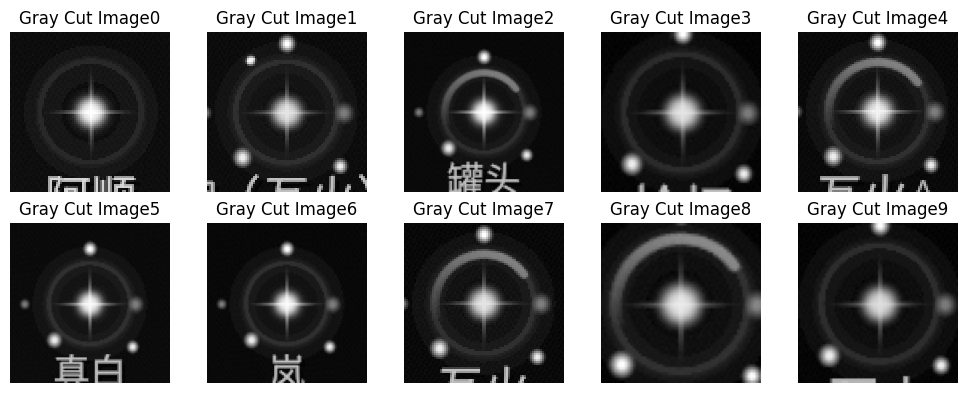

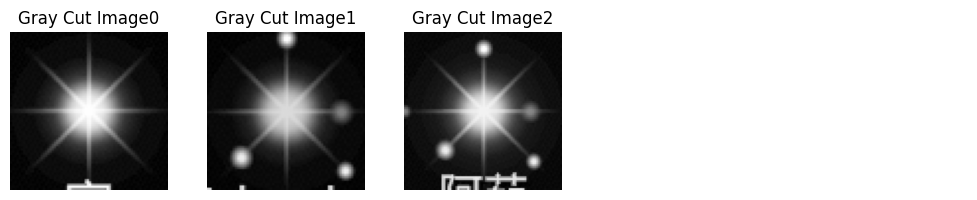

In [12]:
pre_scaler, post_scaler = 5, 2
pre_sub_gray = [gray[int(y-max(w,h)*pre_scaler):int(y+max(w, h)*pre_scaler), int(x-max(w, h)*pre_scaler):int(x+max(w, h)*pre_scaler)] for x, y, w, h in pre]
post_sub_gray = [gray[int(y-max(w,h)*post_scaler):int(y+max(w, h)*post_scaler), int(x-max(w, h)*post_scaler):int(x+max(w, h)*post_scaler)] for x, y, w, h in post]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(pre_sub_gray):
        ax.imshow(pre_sub_gray[i], cmap='gray')
        ax.set_title('Gray Cut Image{}'.format(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes.flatten()):
    if i < len(post_sub_gray):
        ax.imshow(post_sub_gray[i], cmap='gray')
        ax.set_title('Gray Cut Image{}'.format(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

---
# 检测星星周围是否有星屑

In [13]:
# 加载我们的 ResNet18 模型
# model = resnet18()
# model.load_state_dict(torch.load(os.path.join("models", "hearts.pth"), weights_only=True))